# CEED Events Catalog Exploration

This notebook loads the CEED preprocessed event catalog and computes:
- event counts by magnitude level
- event counts by our magnitude-based class labels

The class mapping uses the default bins `[5.0, 6.0, 7.0]` from the project label generation code.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path('data/CEED/events.csv')
print('Loading file:', data_path)
events = pd.read_csv(data_path)
events['magnitude'] = pd.to_numeric(events['magnitude'], errors='coerce')
print('Data shape:', events.shape)
events.head()

Loading file: data/CEED/events.csv
Data shape: (653642, 14)


,begin_time,depth_km,end_time,event_id,event_time,event_time_index,latitude,longitude,magnitude,magnitude_type,nt,nx,sampling_rate,source
0,1987-10-12T11:03:31.620000,3.99,1987-10-12T11:05:31.620000,nc10085297,1987-10-12T11:04:00.330000,2871,35.565167,-120.871167,1.66,D,12000,11,100,NC
1,1987-10-24T19:04:19.230000,0.30,1987-10-24T19:06:19.230000,nc10085386,1987-10-24T19:04:42.400000,2317,34.483000,-120.959667,2.85,D,12000,13,100,NC
2,1988-02-12T20:19:41.790000,7.52,1988-02-12T20:21:41.790000,nc10086582,1988-02-12T20:20:09.690000,2790,35.618833,-121.110833,2.07,D,12000,7,100,NC
3,1988-05-10T00:21:31.050000,3.56,1988-05-10T00:23:31.050000,nc10087081,1988-05-10T00:21:57.160000,2611,35.764500,-121.534167,2.35,D,12000,12,100,NC
4,1988-07-26T14:06:58.170000,14.53,1988-07-26T14:08:58.170000,nc10087775,1988-07-26T14:07:24.720000,2655,34.561000,-120.713667,2.62,D,12000,13,100,NC


In [8]:
print('Columns:')
print(events.columns.tolist())
print('Magnitude summary:')
print(events['magnitude'].describe())

mag_counts = events['magnitude'].value_counts().sort_index()
print('Top magnitude levels by count:')
display(mag_counts.head(5))

mag_count_by_rounded = events['magnitude'].round().value_counts().sort_index()
print('Counts by magnitude (rounded to 0.1):')
display(mag_count_by_rounded.head(10))

Columns:
['begin_time', 'depth_km', 'end_time', 'event_id', 'event_time', 'event_time_index', 'latitude', 'longitude', 'magnitude', 'magnitude_type', 'nt', 'nx', 'sampling_rate', 'source']
Magnitude summary:
count    653642.000000
mean          1.207645
std           0.714716
min          -0.880000
25%           0.700000
50%           1.120000
75%           1.610000
max           7.200000
Name: magnitude, dtype: float64
Top magnitude levels by count:


magnitude
-0.88    1
-0.81    1
-0.75    1
-0.74    2
-0.73    1
Name: count, dtype: int64

Counts by magnitude (rounded to 0.1):


magnitude
-1.0        98
-0.0    101271
 1.0    355881
 2.0    162967
 3.0     29511
 4.0      3544
 5.0       322
 6.0        45
 7.0         3
Name: count, dtype: int64

Train events (<= 2010): 194,636
Test events (> 2010): 459,006

Train counts by magnitude class:


mag_class_label
<5.0       194590
5.0-5.9        41
6.0-6.9         4
>=7.0           1
Name: count, dtype: int64


Test counts by magnitude class:


mag_class_label
<5.0       458930
5.0-5.9        64
6.0-6.9        11
>=7.0           1
Name: count, dtype: int64

/tmp/ipykernel_31937/3281401147.py:40: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, counts.max() * 1.12 if counts.max() > 0 else 1)


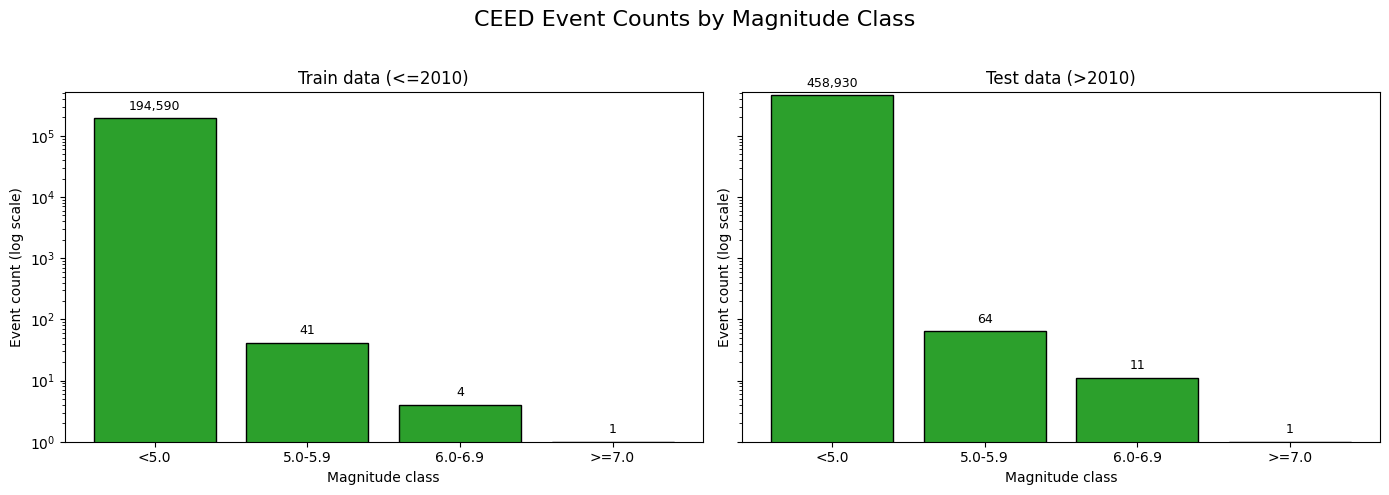

In [10]:
mag_bins = [5.0, 6.0, 7.0]

def magnitude_to_class(max_magnitude, thresholds):
    class_idx = 0
    for threshold in thresholds:
        if max_magnitude >= threshold:
            class_idx += 1
    return class_idx

# Use event_time to split train/test by year
events['year'] = pd.to_datetime(events['event_time'], errors='coerce').dt.year
events['mag_class'] = events['magnitude'].fillna(-float('inf')).apply(lambda m: magnitude_to_class(m, mag_bins))
class_names = {0: '<5.0', 1: '5.0-5.9', 2: '6.0-6.9', 3: '>=7.0'}
ordered_labels = list(class_names.values())
events['mag_class_label'] = events['mag_class'].map(class_names)

train_events = events[events['year'] <= 2010]
test_events = events[events['year'] > 2010]

print(f"Train events (<= 2010): {len(train_events):,}")
print(f"Test events (> 2010): {len(test_events):,}")

train_counts = train_events['mag_class_label'].value_counts().reindex(ordered_labels, fill_value=0)
test_counts = test_events['mag_class_label'].value_counts().reindex(ordered_labels, fill_value=0)

print('\nTrain counts by magnitude class:')
display(train_counts)
print('\nTest counts by magnitude class:')
display(test_counts)

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    def plot_counts(ax, counts, title):
        bars = ax.bar(ordered_labels, counts, color=['#2ca02c'] * len(counts), edgecolor='black')
        ax.set_title(title)
        ax.set_xlabel('Magnitude class')
        ax.set_ylabel('Event count')
        ax.set_ylim(0, counts.max() * 1.12 if counts.max() > 0 else 1)
        if (counts > 0).all():
            ax.set_yscale('log')
            ax.set_ylabel('Event count (log scale)')

        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f'{int(height):,}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=9,
                color='black',
            )

    plot_counts(axes[0], train_counts, 'Train data (<=2010)')
    plot_counts(axes[1], test_counts, 'Test data (>2010)')
    fig.suptitle('CEED Event Counts by Magnitude Class', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
except ImportError:
    print('matplotlib is not installed; skipping chart.')